# Eye-Signal Check

Loads the exported per-trial analog `.mat`, aligns the eye X/Y traces to the go cue
(fixation offset), groups trials by the chosen-target direction, and plots them so eye
tracking for a session can be visually sanity-checked.

> Requires `Blackrock_YYYY-MM-DD_analog.mat`. Produce it first by running the loader with
> `load_analog=True` (see `01_load_and_export.ipynb`).

In [1]:
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat

## 1. Configure data paths & plot settings

Mirrors section 1 of `BlackRockFileAnalyzer.m`. The analog `.mat` lives next to the
`_trials.csv` in the same export folder.

In [2]:
# ── Edit these ──────────────────────────────────────────────────────
MONKEY     = "Monkey Porthos"
BASIC_PATH = "/Users/xuefeiyu/Documents/XuefeiFile/WorkRelated/Data"
LOCATION   = "in_lab"
DATA_DATE  = "2026-06-18"          # session folder, yyyy-mm-dd

ANALYZE_TASK = "time_delay_experiment"   # Task field used to filter trials

# Eye-trace plot settings xw
EYE_PRE_MS     = 300     # ms before go cue (fixation offset) to plot
EYE_POST_MS    = 500     # ms after  go cue to plot
ANGLE_BIN_DEG  = 30      # round chosen-target angle to this grid to form direction groups
EYE_NUM_SAMPLE = 100     # None = plot all trials; N = first N traces per direction
# ────────────────────────────────────────────────────────

export_dir  = Path(BASIC_PATH) / MONKEY / LOCATION / "export_data" / DATA_DATE
CSV_PATH    = export_dir / f"Blackrock_{DATA_DATE}_trials.csv"
ANALOG_PATH = export_dir / f"Blackrock_{DATA_DATE}_analog.mat"
TITLE       = f"{MONKEY}  {DATA_DATE}"

print("Trials CSV :", CSV_PATH)
print("Analog MAT :", ANALOG_PATH)

Trials CSV : /Users/xuefeiyu/Documents/XuefeiFile/WorkRelated/Data/Monkey Porthos/in_lab/export_data/2026-06-18/Blackrock_2026-06-18_trials.csv
Analog MAT : /Users/xuefeiyu/Documents/XuefeiFile/WorkRelated/Data/Monkey Porthos/in_lab/export_data/2026-06-18/Blackrock_2026-06-18_analog.mat


## 2. Load & filter trials

Keep only complete, correct-task, valid-choice trials — the same `selected_data` mask the
MATLAB script uses. The **full-length** boolean mask is kept because the analog trial
dimension is index-aligned 1:1 with every CSV row.

In [3]:
df = pd.read_csv(CSV_PATH)

complete     = df["Save_complete"] == 1
correct_task = df["Task"] == ANALYZE_TASK
valid_choice = df["Choose_target"].notna()

selected  = complete & correct_task & valid_choice   # full-length mask (len == n analog trials)
task_data = df[selected].reset_index(drop=True)

print(f"Loaded {len(df)} trials from {CSV_PATH.name}")
print(f"Complete / correct task / valid choice: {selected.sum()}  ← using these")

Loaded 4804 trials from Blackrock_2026-06-18_trials.csv
Complete / correct task / valid choice: 2973  ← using these


## 3. Load segmented analog (eye) `.mat`

`loadmat(..., squeeze_me=True, struct_as_record=False)` returns the `analog` struct with
attribute access: `analog.data` `(nChan, nTrials, nSamp)` (channel 0 = eye X, 1 = eye Y),
`analog.timeseq.relative_time` (seconds, **0 at the Start marker**).

In [4]:
have_analog = ANALOG_PATH.exists()

if have_analog:
    mat = loadmat(ANALOG_PATH, squeeze_me=True, struct_as_record=False)
    analog = mat["analog"]
    print(f"Loaded analog: data shape {analog.data.shape}  (nChan, nTrials, nSamp)")
else:
    print("No analog (eye) .mat found; run the loader with load_analog=True first.")

Loaded analog: data shape (3, 4804, 8795)  (nChan, nTrials, nSamp)


## 4. Subset to selected trials & extract eye X/Y

Mirrors `subsetAnalogTrials`: slice the analog trial dimension with the same `selected` mask
so eye traces line up with `task_data`. `marker_time` is the go cue (fixation offset) in the
same clock as `eye_time` (both measured from the Start marker).

In [5]:
if have_analog:
    sel = selected.values
    eye_x    = np.asarray(analog.data[0])[sel]                 # nTrials x nSamp
    eye_y    = np.asarray(analog.data[1])[sel]
    eye_time = np.asarray(analog.timeseq.relative_time, dtype=float)   # nSamp, s from Start

    # Go cue (fixation offset) time relative to Start, per trial.
    marker_time = (task_data["Fixation_point_off"] - task_data["Start"]).to_numpy(dtype=float)

    print(f"eye_x/eye_y: {eye_x.shape}   eye_time: {eye_time.shape}")

eye_x/eye_y: (2973, 8795)   eye_time: (8795,)


## 5. Align eye traces to the go cue

Port of `AlignEyeTrace`: resample every trial onto one shared axis with 0 at the marker,
over `[-EYE_PRE_MS, +EYE_POST_MS]`. Linear interpolation over each trial's non-NaN samples;
points outside the available data are set to NaN (matching MATLAB `interp1(..., 'linear', NaN)`,
since `np.interp` would otherwise clamp to the edge values).

In [6]:
def align_eye_trace(eye_x, eye_y, eye_time, marker_time, pre_ms, post_ms):
    """Re-align eye traces to a per-trial marker (e.g. fixation offset / go cue).

    Returns (aligned_x, aligned_y, rel_t) where aligned_* are (nTrials, nOut),
    NaN outside available data, and rel_t is time from the marker (s), 0 at the marker.
    """
    eye_time = np.asarray(eye_time, dtype=float).ravel()
    n_tr     = eye_x.shape[0]

    step_s = np.median(np.diff(eye_time))                 # native sample interval (s)
    n_pre  = int(round((pre_ms / 1000.0) / step_s))
    n_post = int(round((post_ms / 1000.0) / step_s))
    rel_t  = np.arange(-n_pre, n_post + 1) * step_s        # 1 x nOut, 0 = marker

    ax = np.full((n_tr, rel_t.size), np.nan)
    ay = np.full((n_tr, rel_t.size), np.nan)
    for i in range(n_tr):
        if math.isnan(marker_time[i]):
            continue
        valid = ~np.isnan(eye_x[i]) & ~np.isnan(eye_y[i])   # drop NaN-padded tail
        if valid.sum() < 2:
            continue
        t_valid = eye_time[valid]
        sample_s = marker_time[i] + rel_t                   # where to sample eye_time
        in_range = (sample_s >= t_valid.min()) & (sample_s <= t_valid.max())
        ax[i, in_range] = np.interp(sample_s[in_range], t_valid, eye_x[i][valid])
        ay[i, in_range] = np.interp(sample_s[in_range], t_valid, eye_y[i][valid])
    return ax, ay, rel_t


if have_analog:
    aligned_x, aligned_y, rel_t = align_eye_trace(
        eye_x, eye_y, eye_time, marker_time, EYE_PRE_MS, EYE_POST_MS
    )
    print(f"Aligned to fixation off: {aligned_x.shape}  over [{rel_t[0]*1000:.0f}, {rel_t[-1]*1000:.0f}] ms")

Aligned to fixation off: (2973, 801)  over [-300, 500] ms


## 6. Group trials by chosen-target direction

Condition = the angle of the chosen target, binned to `ANGLE_BIN_DEG` and wrapped to
`(-180, 180]`

In [7]:
if have_analog:
    choose = task_data["Choose_target"].to_numpy(dtype=float)
    ang = np.full(len(task_data), np.nan)
    ang[choose == 1] = task_data["Target_1_angle"].to_numpy(dtype=float)[choose == 1]
    ang[choose == 2] = task_data["Target_2_angle"].to_numpy(dtype=float)[choose == 2]

    conditions = (np.round(ang / ANGLE_BIN_DEG) * ANGLE_BIN_DEG + 180) % 360 - 180
    print("Direction groups (deg):", np.unique(conditions[~np.isnan(conditions)]))

Direction groups (deg): [-90.  90.]


## 7. Plot — eye X/Y vs time, one subplot per direction

X solid, Y dashed. Vertical dotted line marks the go cue (t = 0). Port of
`plotAlignedEyeTraces` figure 1.

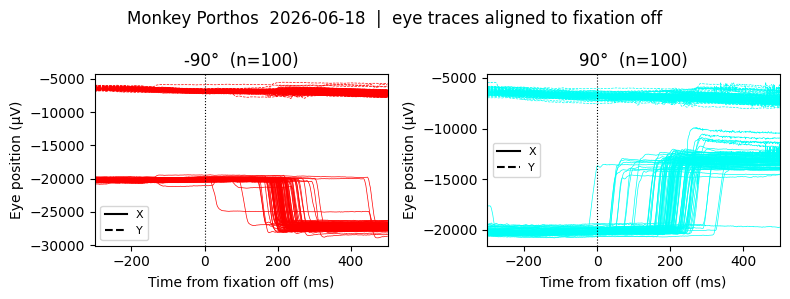

In [8]:
if have_analog:
    tt_ms = rel_t * 1000.0

    # Keep trials with a defined condition and some data.
    keep = ~np.isnan(conditions) & np.any(~np.isnan(aligned_x), axis=1)
    Xk, Yk, condk = aligned_x[keep], aligned_y[keep], conditions[keep]

    if not keep.any():
        print("No trials with a valid condition / data.")
    else:
        groups = np.unique(condk)
        n_grp  = groups.size
        cmap   = plt.cm.hsv(np.linspace(0, 1, n_grp, endpoint=False))
        nc = math.ceil(math.sqrt(n_grp))
        nr = math.ceil(n_grp / nc)

        fig, axes = plt.subplots(nr, nc, figsize=(4 * nc, 3 * nr), squeeze=False)
        for d, g in enumerate(groups):
            ax = axes[d // nc][d % nc]
            idx = np.flatnonzero(condk == g)
            if EYE_NUM_SAMPLE is not None:
                idx = idx[:EYE_NUM_SAMPLE]
            ax.plot(tt_ms, Xk[idx].T, "-",  color=cmap[d], lw=0.5)
            ax.plot(tt_ms, Yk[idx].T, "--", color=cmap[d], lw=0.5)
            ax.axvline(0, color="k", ls=":", lw=0.8)          # go cue at t=0
            ax.set_xlim(tt_ms[0], tt_ms[-1])
            ax.set_xlabel("Time from fixation off (ms)")
            ax.set_ylabel("Eye position (µV)")
            ax.set_title(f"{g:.0f}°  (n={idx.size})")
            ax.plot([], [], "-k",  label="X")
            ax.plot([], [], "--k", label="Y")
            ax.legend(loc="best", fontsize=8)
        # Hide any unused axes in the grid.
        for d in range(n_grp, nr * nc):
            axes[d // nc][d % nc].axis("off")
        fig.suptitle(f"{TITLE}  |  eye traces aligned to fixation off")
        fig.tight_layout()
        plt.show()

## 8. Plot — 2D gaze trajectory, one color per direction

Port of `plotAlignedEyeTraces` figure 2.

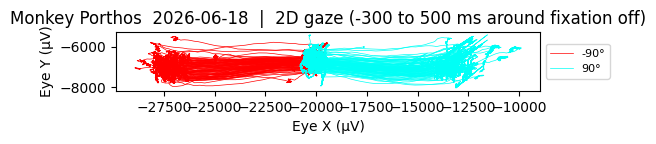

In [9]:
if have_analog and keep.any():
    fig, ax = plt.subplots(figsize=(6, 6))
    for d, g in enumerate(groups):
        idx = np.flatnonzero(condk == g)
        if EYE_NUM_SAMPLE is not None:
            idx = idx[:EYE_NUM_SAMPLE]
        for k, tr in enumerate(idx):
            ax.plot(
                Xk[tr], Yk[tr], "-", color=cmap[d], lw=0.5,
                label=f"{g:.0f}°" if k == 0 else None,
            )
    ax.set_aspect("equal")
    ax.set_xlabel("Eye X (µV)")
    ax.set_ylabel("Eye Y (µV)")
    ax.set_title(f"{TITLE}  |  2D gaze ({tt_ms[0]:.0f} to {tt_ms[-1]:.0f} ms around fixation off)")
    ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=8)
    fig.tight_layout()
    plt.show()